# Постановка задачи

\begin{equation*}
    \begin{cases}
        \dfrac{\partial h}{\partial t} + \dfrac{\partial (hu)}{\partial x} = 0, \\[10pt]
        \dfrac{\partial (hu)}{\partial t} + \dfrac{\partial}{\partial x} \left( h u^2 + \dfrac{g h^2}{2} \right) = 0,
    \end{cases}
\end{equation*}

\begin{equation*}
    x \in [-2.5, 4.0], \quad t \in [0, 1.0].
\end{equation*}

\begin{equation*}
    \begin{cases}
        h(x, 0) = 1.0 + 1.2 \exp\left(-\dfrac{x^2}{0.3}\right), \\[10pt]
        u(x, 0) = 0.
    \end{cases}
\end{equation*}

In [135]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from scipy.integrate import solve_ivp

In [136]:
g = 9.81

x = np.linspace(-2.5, 8.0, 400)
t = np.linspace(0, 1.0, 200)

h0 = 1.0 + 1.2 * np.exp(-x**2 / 0.3)
u0 = np.zeros_like(x)

#h0 = 1.5 - 0.5 * np.tanh(3.0 * x)
#u0 = np.zeros_like(x)

#h0 = 1.0 + 0.8 * np.exp(-x**2 / 0.5)
#u0 = 2.0 * (np.sqrt(g * h0) - np.sqrt(g * 1.0))

#h0 = np.full_like(x, 1.2)
#u0 = 1.5 * np.exp(-x**2 / 0.3)

c0 = np.sqrt(g * h0)

Rp0 = u0 + 2 * c0
Rm0 = u0 - 2 * c0

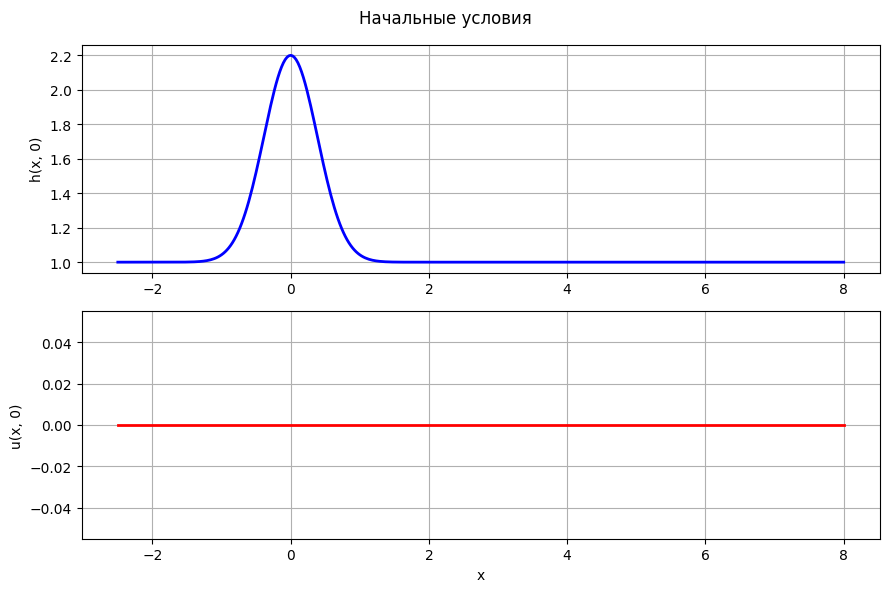

In [137]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
axes[0].plot(x, h0, "b", lw=2)
axes[0].set_ylabel("h(x, 0)")
axes[0].grid(True)
axes[1].plot(x, u0, "r", lw=2)
axes[1].set_xlabel("x")
axes[1].set_ylabel("u(x, 0)")
axes[1].grid(True)
plt.suptitle("Начальные условия")
plt.tight_layout()
plt.show()

\begin{equation*}
    R_+ = u + 2c = \text{const вдоль } C_+, \quad R_- = u - 2c = \text{const вдоль } C_-.
\end{equation*}

\begin{equation*}
    \begin{cases}
        \lambda_+ = u + c = \dfrac{3}{4}R_+ + \dfrac{1}{4}R_- \\[10pt]
        \lambda_- = u - c = \dfrac{1}{4}R_+ + \dfrac{3}{4}R_-
    \end{cases}
\end{equation*}

Пусть $x_+^{(i)}(t)$ и $x_-^{(i)}(t)$ — пространственные координаты $i$-й характеристики семейств $C_+$ и $C_-$ соответственно.
Тогда:
\begin{equation*}
    \begin{cases}
        \dfrac{dx_+^{(i)}}{dt} = \dfrac{3}{4} R_{+,0}^{(i)} + \dfrac{1}{4} \tilde{R}_-\left(x_+^{(i)}(t), t\right), \\[12pt]
        \dfrac{dx_-^{(i)}}{dt} = \dfrac{1}{4} \tilde{R}_+\left(x_-^{(i)}(t), t\right) + \dfrac{3}{4} R_{-,0}^{(i)},
    \end{cases}
\end{equation*}

Величины $\tilde{R}_-$ и $\tilde{R}_+$ - значения встречных инвариантов. Так как встречные характеристики движутся по своим траекториям, для вычисления скорости в точке $x_+^{(i)}(t)$ необходимо найти значение $R_-$ путем пространственной интерполяции значений $R_{-,0}^{(j)}$, заданных на узлах $x_-^{(j)}(t)$:
\begin{equation*}
    \tilde{R}_-\left(x_+^{(i)}, t\right) = \text{Interp}\left( \text{узлы: } x_-^{(j)}(t), \text{ значения: } R_{-,0}^{(j)}, \text{ точка: } x_+^{(i)}(t) \right).
\end{equation*}

Начальные условия для системы ОДУ:
\begin{equation*}
    x_+^{(i)}(0) = x_0^{(i)}, \quad x_-^{(i)}(0) = x_0^{(i)}.
\end{equation*}


In [138]:
def moc_odes(t, W):
    M = len(x)
    xp = W[:M]
    xm = W[M:]

    idx_m = np.argsort(xm)
    Rm_at_xp = np.interp(xp, xm[idx_m], Rm0[idx_m])

    idx_p = np.argsort(xp)
    Rp_at_xm = np.interp(xm, xp[idx_p], Rp0[idx_p])

    dxp = 0.75 * Rp0 + 0.25 * Rm_at_xp
    dxm = 0.25 * Rp_at_xm + 0.75 * Rm0

    return np.concatenate([dxp, dxm])

W0 = np.concatenate([x, x])
sol = solve_ivp(moc_odes, [0, 2.0], W0, t_eval=t, method="RK45")
xp_t = sol.y[:len(x), :]
xm_t = sol.y[len(x):, :]

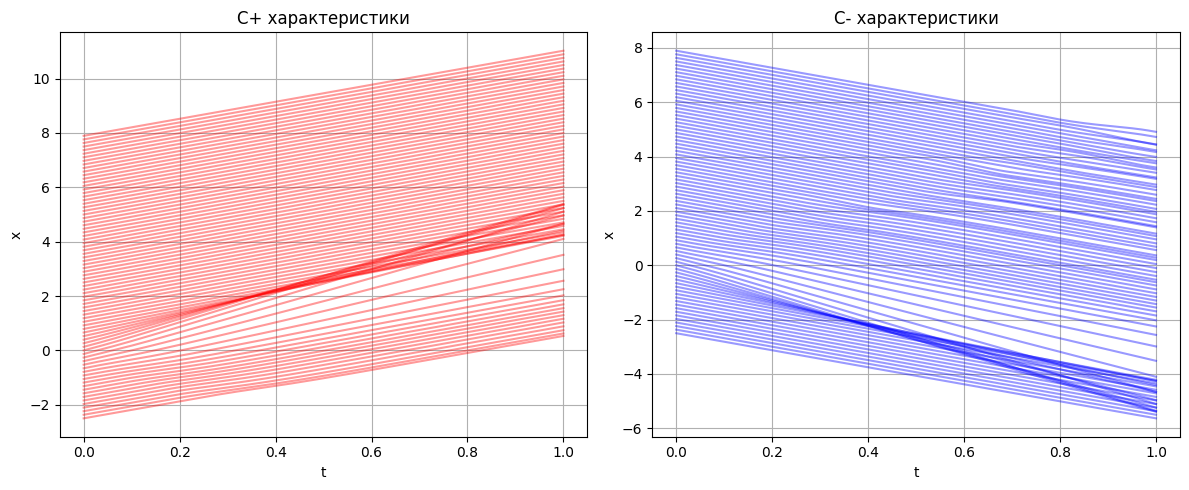

In [139]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for i in range(0, len(x), 5):
    ax1.plot(t, xp_t[i, :], "r-", alpha=0.4)
    ax2.plot(t, xm_t[i, :], "b-", alpha=0.4)
ax1.set_title("С+ характеристики")
ax1.set_xlabel("t")
ax1.set_ylabel("x")
ax1.grid(True)
ax2.set_title("С- характеристики")
ax2.set_xlabel("t")
ax2.set_ylabel("x")
ax2.grid(True)
plt.tight_layout()
plt.show()

Формирование разрыва (ударной волны) в нелинейной задаче мелкой воды начинается с момента опрокидывания волны. Геометрически это явление соответствует пересечению характеристик одного семейства (в нашем случае — характеристик $C_+$), идущих из разных точек начального профиля.

Момент образования каустики:
\begin{equation*}
    \left| \frac{\partial h}{\partial x} \right| \to \infty, \quad \left| \frac{\partial u}{\partial x} \right| \to \infty.
\end{equation*}
Т.е:
\begin{equation*}
    \frac{\partial x_+(x_0, t)}{\partial x_0} = 0.
\end{equation*}

Аппроксимируем:
\begin{equation*}
    \frac{\partial x_+}{\partial x_0} \approx \frac{x_+^{(k+1)}(t) - x_+^{(k)}(t)}{x_0^{(k+1)} - x_0^{(k)}}.
\end{equation*}

Условием пересечения характеристик является нарушение монотонности текущих координат $x_+^{(k)}$. Проверяем выполнение условия:
\begin{equation*}
    \exists k : \quad \Delta X_+^{(k)}(t_n) \equiv X_+^{(k+1)}(t_n) - X_+^{(k)}(t_n) \le 0.
\end{equation*}

Момент времени $t_n$, при котором данное условие выполняется впервые, фиксируется как время зарождения каустики $t_{caustic}$.

Для определения пространственной координаты каустики $x_{caustic}$ ищем индекс $k_{min}$, соответствующий
\begin{equation*}
    k_{min} = \arg\min_k \left( \Delta x_+^{(k)}(t_n) \right).
\end{equation*}
Координата каустики тогда принимается равной $x_{caustic} = x_+^{(k_{min})}(t_{caustic})$.


In [140]:
t_c_idx = -1
t_caustic = None
x_caustic = None

for i in range(len(t)):
    if np.any(np.diff(xp_t[:, i]) <= 0):
        t_c_idx = i
        t_caustic = t[i]
        min_idx = np.argmin(np.diff(xp_t[:, i]))
        x_caustic = xp_t[min_idx, i]
        break

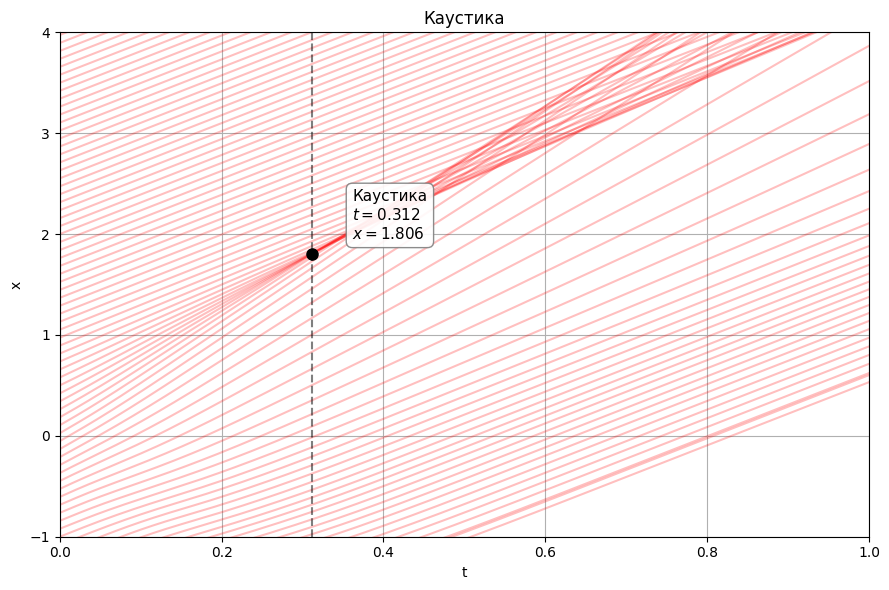

In [141]:
fig, ax = plt.subplots(figsize=(9, 6))

for i in range(0, len(x), 3):
    ax.plot(t, xp_t[i, :], "r-", alpha=0.25)

if t_caustic is not None:
    ax.plot(t_caustic, x_caustic, "ko", markersize=8)
    ax.axvline(t_caustic, color="k", linestyle="--", alpha=0.5)

    text_label = f"Каустика\n$t = {t_caustic:.3f}$\n$x = {x_caustic:.3f}$"
    ax.annotate(
        text_label,
        xy=(t_caustic, x_caustic),
        xytext=(t_caustic + 0.05, x_caustic + 0.15),
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

ax.set_title("Каустика")
ax.set_xlabel("t")
ax.set_ylabel("x")
ax.set_xlim(0, 1.0)
ax.set_ylim(-1, 4)
ax.grid(True)
plt.tight_layout()
plt.show()

1. Восстановление физических переменных

В каждый момент времени $t$ известны координаты характеристик $x_+^{(k)}$ и $x_-^{(k)}$. Вдоль характеристик $C_+$ сохраняется инвариант $R_+(x_+, t) \equiv R_{+,0}$. Для вычисления второго инварианта в точках $x_+$ применяется линейная интерполяция со встречной сетки $x_-$ (аналогично тому, как это делалось при интегрировании ОДУ):
\begin{equation*}
    \tilde{R}_-\left(x_+^{(k)}, t\right) = \text{Interp}\left( x_-^{(j)}, R_{-,0}^{(j)}, x_+^{(k)} \right).
\end{equation*}
Имея оба инварианта Римана в координатах $X_+$, можно однозначно восстановить физические переменные — скорость потока $u$ и глубину $h$:
\begin{equation*}
    u\left(x_+^{(k)}, t\right) = \frac{1}{2}\left( R_{+,0}^{(k)} + \tilde{R}_- \right), \quad
    c\left(x_+^{(k)}, t\right) = \frac{1}{4}\left( R_{+,0}^{(k)} - \tilde{R}_- \right), \quad
    h\left(x_+^{(k)}, t\right) = \frac{c^2}{g}.
\end{equation*}

2. Отслеживание фронта ударной волны (сшивка многозначности)

После формирования каустики ($t > t_{caustic}$) решение, полученное методом характеристик, становится многозначным. Для устранения многозначности вводится сильный разрыв — ударная волна, координата которой $x_s(t)$ удовлетворяет обыкновенному дифференциальному уравнению:
\begin{equation*}
    \frac{dx_s}{dt} = S(t), \quad x_s(t_{caustic}) = x_{caustic},
\end{equation*}
где $S(t)$ — скорость распространения ударной волны.

Для нахождения $S(t)$ на каждом временном шаге определяется пересечение $x = x_s(t_{n-1})$ с многозначным профилем характеристик. Ищем отрезки между соседними узлами сетки характеристик $[x_+^{(k)}, x_+^{(k+1)}]$, которые содержат точку $x_s$. Это проверяется условием:
\begin{equation*}
    \left(x_+^{(k)} - x_s\right) \cdot \left(x_+^{(k+1)} - x_s\right) \le 0.
\end{equation*}
Внутри найденных отрезков значения $h$ и $u$ вычисляются с помощью линейной интерполяции с весом $w \in [0, 1]$:
\begin{equation*}
    w = \frac{x_s - x_+^{(k)}}{X_+^{(k+1)} - x_+^{(k)}} \quad \implies \quad h_{int} = h^{(k)} + w\left(h^{(k+1)} - h^{(k)}\right).
\end{equation*}

При наличии многозначной петли вертикальная прямая пересекает профиль в трех точках. Чтобы корректно задать состояния слева ($L$) и справа ($R$) от разрыва, точки пересечения сортируются по лагранжевой координате.

Скорость ударной волны $S$ определяется из условия Гюгонио-Ренкина для закона сохранения массы:
\begin{equation*}
    -S[h] + [hu] = 0 \quad \implies \quad S = \frac{h_L u_L - h_R u_R}{h_L - h_R},
\end{equation*}
где квадратные скобки обозначают скачок величины на разрыве: $[f] = f_L - f_R$.

Наконец, координата ударной волны обновляется по времени явным методом Эйлера:
\begin{equation*}
    x_s(t_n) = x_s(t_{n-1}) + S \cdot \Delta t.
\end{equation*}


In [142]:
H_p = np.zeros_like(xp_t)
U_p = np.zeros_like(xp_t)
for i_t in range(len(t)):
    xp_curr = xp_t[:, i_t]
    xm_curr = xm_t[:, i_t]
    idx_m = np.argsort(xm_curr)
    Rm_interp = np.interp(xp_curr, xm_curr[idx_m], Rm0[idx_m])
    U_p[:, i_t] = 0.5 * (Rp0 + Rm_interp)
    H_p[:, i_t] = (0.25 * (Rp0 - Rm_interp))**2 / g

xs_path = np.full(len(t), np.nan)
if t_caustic is not None:
    xs_path[t_c_idx] = x_caustic
    for i_t in range(t_c_idx + 1, len(t)):
        xs_prev = xs_path[i_t - 1]
        xp_curr = xp_t[:, i_t-1]
        Hp_curr = H_p[:, i_t-1]
        Up_curr = U_p[:, i_t-1]

        roots_idx = []
        for k in range(len(xp_curr) - 1):
            if (xp_curr[k] - xs_prev) * (xp_curr[k+1] - xs_prev) <= 0:
                dx = xp_curr[k+1] - xp_curr[k]
                if abs(dx) > 1e-12:
                    w = (xs_prev - xp_curr[k]) / dx
                    h_val = Hp_curr[k] + w * (Hp_curr[k+1] - Hp_curr[k])
                    u_val = Up_curr[k] + w * (Up_curr[k+1] - Up_curr[k])
                    roots_idx.append((k + w, h_val, u_val))

        if len(roots_idx) >= 3:
            roots_idx.sort(key=lambda x: x[0])
            hL, uL = roots_idx[0][1], roots_idx[0][2]
            hR, uR = roots_idx[-1][1], roots_idx[-1][2]
            s = (hL * uL - hR * uR) / (hL - hR + 1e-12)
            #s = uR + np.sqrt(g * hL / (2 * hR) * (hL + hR))
        elif len(roots_idx) >= 1:
            s = roots_idx[0][2] + np.sqrt(g * roots_idx[0][1])
        else:
            s = 0

        dt = t[i_t] - t[i_t - 1]
        xs_path[i_t] = xs_prev + s * dt

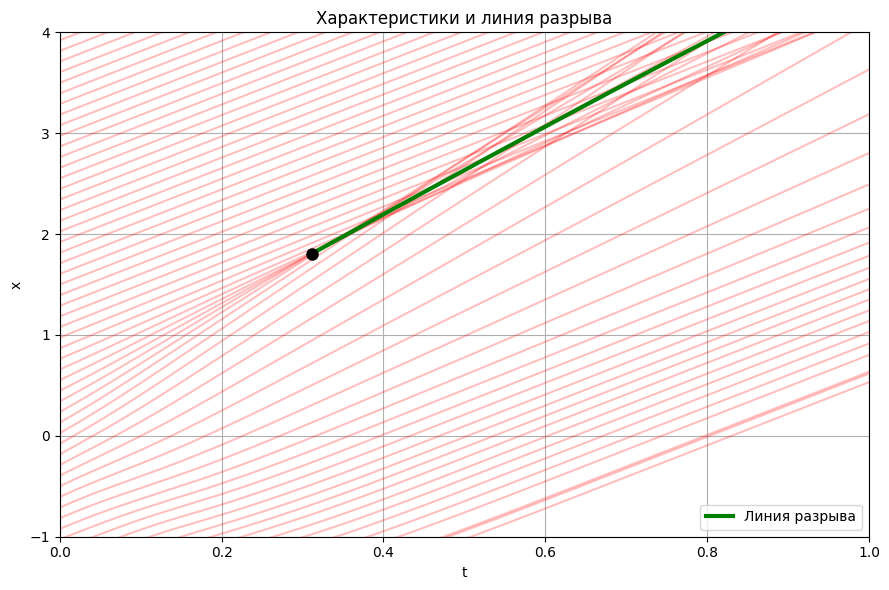

In [143]:
fig, ax = plt.subplots(figsize=(9, 6))
for i in range(0, len(x), 4):
    ax.plot(t, xp_t[i, :], "r-", alpha=0.25)
if t_caustic is not None:
    ax.plot(t, xs_path, "g-", lw=3, label="Линия разрыва")
    ax.plot(t_caustic, x_caustic, "ko", markersize=8)
    ax.legend()
ax.set_title("Характеристики и линия разрыва")
ax.set_xlabel("t")
ax.set_ylabel("x")
ax.set_xlim(0, 1.0)
ax.set_ylim(-1, 4)
ax.grid(True)
plt.tight_layout()
plt.show()

Метод характеристик после момента опрокидывания ($t > t_{caustic}$) дает математически гладкое, но физически недопустимое многозначное решение. Для построения физического слабого решения необходимо исключить нефизичную многозначность, заменив её вертикальным скачком.

#### Локализация области складки

Определяется диапазон лагранжевых индексов (номеров узлов), на котором нарушается монотонность профиля:
\begin{equation*}
    \Delta x_+^{(k)} \le 0.
\end{equation*}
Пусть $k_{start}$ — индекс начала опрокидывания, а $k_{end}$ — индекс его окончания. Таким образом, весь профиль характеристик разделяется на три участка:
1. Левая (набегающая) однозначная ветвь: $k \le k_{start}$.
2. Нефизичная "перевернутая" складка: $k_{start} < k < k_{end}$ (эта часть полностью отбрасывается).
3. Правая (невозмущенная) однозначная ветвь: $k \ge k_{end}$.

#### Усечение ветвей по координате ударной волны

Поскольку ударная волна "съедает" часть характеристик перед собой и позади себя, левая и правая ветви дополнительно усекаются так, чтобы они не заходили за линию разрыва $x_s$.

#### Вычисление точных состояний на границах разрыва

Для замыкания профиля необходимо определить предельные значения глубины слева ($h_L$) и справа ($h_R$) от бесконечно тонкого разрыва:
\begin{equation*}
    h_L = \lim_{x \to x_s - 0} h(x, t), \quad h_R = \lim_{x \to x_s + 0} h(x, t).
\end{equation*}

#### Сборка итогового решения (сшивка)
Результирующее однозначное поле пространственных координат $\tilde{X}$ и поля глубины $\tilde{H}$ собираются конкатенацией (объединением) трех блоков:
\begin{equation*}
    \tilde{X} =
    \underbrace{\left\{ x_+^{(k)} \right\}_{k \le k_{start}}^{x_+ \le x_s}}_{\text{Левая ветвь}}
    \cup
    \underbrace{\{ x_s, \, x_s \}}_{\text{Скачок}}
    \cup
    \underbrace{\left\{ x_+^{(k)} \right\}_{k \ge k_{end}}^{x_+ > x_s}}_{\text{Правая ветвь}},
\end{equation*}

In [144]:
def get_single_valued(xp, Hp, xs):
    if np.isnan(xs):
        return xp, Hp

    diff_xp = np.diff(xp)
    folds = np.where(diff_xp <= 0)[0]

    if len(folds) == 0:
        return xp, Hp

    step = np.where(np.diff(folds) != 1)[0] + 1
    fold_groups = np.split(folds, step)

    target_group = fold_groups[0]
    for group in fold_groups:
        idx_start = group[0]
        idx_end = group[-1] + 1
        x_min = np.min(xp[idx_start:idx_end+1])
        x_max = np.max(xp[idx_start:idx_end+1])

        if x_min - 0.1 <= xs <= x_max + 0.1:
            target_group = group
            break

    f1 = target_group[0]
    f2 = target_group[-1] + 1

    mask1 = xp[:f1+1] <= xs
    mask2 = xp[f2:] > xs

    hL = np.interp(xs, xp[:f1+1], Hp[:f1+1])
    hR = np.interp(xs, xp[f2:], Hp[f2:])

    X_sv = np.concatenate([xp[:f1+1][mask1], [xs, xs], xp[f2:][mask2]])
    H_sv = np.concatenate([Hp[:f1+1][mask1], [hL, hR], Hp[f2:][mask2]])

    return X_sv, H_sv

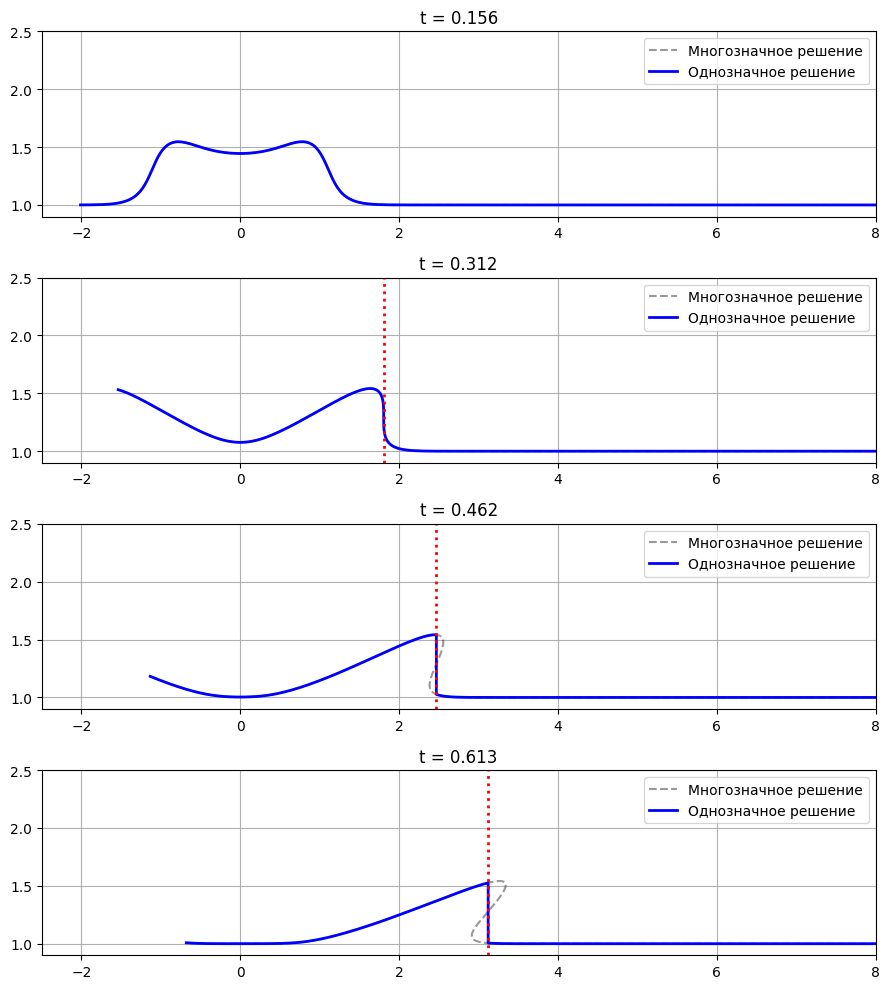

In [145]:
if t_caustic is not None:
    plot_times = [t_caustic / 2, t_caustic, t_caustic + 0.15, t_caustic + 0.3]
    fig, axes = plt.subplots(len(plot_times), 1, figsize=(9, 10))
    for ax, pt in zip(axes, plot_times):
        i_t = np.argmin(np.abs(t - pt))
        xp_curr = xp_t[:, i_t]
        Hp_curr = H_p[:, i_t]
        xs = xs_path[i_t]

        ax.plot(xp_curr, Hp_curr, "k--", alpha=0.4, label="Многозначное решение")
        X_sv, H_sv = get_single_valued(xp_curr, Hp_curr, xs)
        ax.plot(X_sv, H_sv, "b-", lw=2, label="Однозначное решение")
        if not np.isnan(xs):
            ax.axvline(xs, color="r", linestyle=":", lw=2)
        ax.set_title(f"t = {t[i_t]:.3f}")
        ax.set_xlim(x[0], x[-1])
        ax.set_ylim(0.9, 2.5)
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()

Реализуем численное решение системы уравнений мелкой воды методом конечных разностей (схема Лакса-Фридрихса) для сравнения с результатами метода характеристик.

Для применения метода Лакса-Фридрихса система уравнений мелкой воды записывается в строгой консервативной форме:
\begin{equation*}
    \frac{\partial \mathbf{Q}}{\partial t} + \frac{\partial \mathbf{F}(\mathbf{Q})}{\partial x} = 0,
\end{equation*}
где $\mathbf{Q}$ — вектор консервативных переменных, $\mathbf{F}(\mathbf{Q})$ — вектор потоков:
\begin{equation*}
    \mathbf{Q} = \begin{pmatrix} q_1 \\ q_2 \end{pmatrix} = \begin{pmatrix} h \\ hu \end{pmatrix}, \quad
    \mathbf{F}(\mathbf{Q}) = \begin{pmatrix} f_1 \\ f_2 \end{pmatrix} = \begin{pmatrix} q_2 \\ \frac{q_2^2}{q_1} + \frac{g q_1^2}{2} \end{pmatrix}.
\end{equation*}

Для численной устойчивости явной схемы шаг по времени $\Delta t$ выбирается динамически на каждой итерации в соответствии с критерием Куранта-Фридрихса-Леви (CFL):
\begin{equation*}
    \Delta t = C_{cfl} \frac{\Delta x}{\max_i \left( |u_i| + c_i \right)},
\end{equation*}

Значения вектора консервативных переменных в узле $i$ на новом временном слое $n+1$ вычисляются по явной центрально-разностной схеме Лакса-Фридрихса первого порядка точности:
\begin{equation*}
    \mathbf{Q}_i^{n+1} = \frac{1}{2}\left( \mathbf{Q}_{i-1}^n + \mathbf{Q}_{i+1}^n \right) - \frac{\Delta t}{2\Delta x}\left( \mathbf{F}_{i+1}^n - \mathbf{F}_{i-1}^n \right).
\end{equation*}
Первое слагаемое $\frac{1}{2}( \mathbf{Q}_{i-1}^n + \mathbf{Q}_{i+1}^n )$ эквивалентно добавлению мощной искусственной (схемной) вязкости, пропорциональной $\sim \frac{\Delta x^2}{\Delta t} \frac{\partial^2 \mathbf{Q}}{\partial x^2}$. Эта вязкость позволяет схеме производить "сквозной" счет через разрывы (опрокидывание волны) без разрушения алгоритма, автоматически выполняя условие Гюгонио-Ренкина, но при этом "размазывая" фронт ударной волны на несколько узлов сетки.


In [146]:
dx_fv = (x[-1] - x[0]) / len(x)
x_fv = x
q1 = h0.copy()
q2 = u0.copy()

H_fv = [q1.copy()]
t_curr = 0.0

for t_next in t[1:]:
    while t_curr < t_next:
        u_max = np.max(np.abs(q2/q1) + np.sqrt(g*q1))
        dt = 0.9 * dx_fv / u_max
        if t_curr + dt > t_next:
            dt = t_next - t_curr

        f1 = q2
        f2 = q2**2 / q1 + 0.5 * g * q1**2

        q1_new = 0.5 * (q1[:-2] + q1[2:]) - 0.5 * dt / dx_fv * (f1[2:] - f1[:-2])
        q2_new = 0.5 * (q2[:-2] + q2[2:]) - 0.5 * dt / dx_fv * (f2[2:] - f2[:-2])

        q1[1:-1] = q1_new
        q2[1:-1] = q2_new
        q1[0], q1[-1] = q1[1], q1[-2]
        q2[0], q2[-1] = q2[1], q2[-2]

        t_curr += dt
    H_fv.append(q1.copy())

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

line_fv, = ax.plot([], [], "b-", lw=2, label="Лакс-Фридрихс")
line_moc, = ax.plot([], [], "r--", lw=2.5, label="Метод характеристик + условие Гюгонио-Ренкина")
line_mv, = ax.plot([], [], "k:", alpha=0.5, label="Метод характеристик")
vline1 = ax.axvline(np.nan, color="g", ls="-", lw=1.5)
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-0.5, 2.5)
ax.set_ylabel("h(x, t)")
ax.legend(loc="upper right")
ax.grid(True)

def update(frame):
    ax.set_title(f"t: {t[frame]:.3f}")
    line_fv.set_data(x_fv, H_fv[frame])

    xp_curr = xp_t[:, frame]
    Hp_curr = H_p[:, frame]
    xs = xs_path[frame]

    line_mv.set_data(xp_curr, Hp_curr)
    X_sv, H_sv = get_single_valued(xp_curr, Hp_curr, xs)
    line_moc.set_data(X_sv, H_sv)

    if not np.isnan(xs):
        vline1.set_xdata([xs, xs])
    else:
        vline1.set_xdata([np.nan, np.nan])

    return line_fv, line_moc, line_mv, vline1

ani = FuncAnimation(fig, update, frames=len(t), interval=50, blit=True)
ani.save("solution.mp4", writer='ffmpeg', fps=1000 / 50, dpi=150)

from IPython.display import HTML
HTML(ani.to_jshtml())